In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

INPUT_DIR = '/kaggle/input/competitions/petfinder-adoption-prediction'
print(os.listdir(INPUT_DIR))

['state_labels.csv', 'train_metadata', 'color_labels.csv', 'StateLabels.csv', 'train_images', 'test_metadata', 'PetFinder-BreedLabels.csv', 'BreedLabels.csv', 'train_sentiment', 'ColorLabels.csv', 'test_sentiment', 'PetFinder-ColorLabels.csv', 'PetFinder-StateLabels.csv', 'test', 'train', 'breed_labels.csv', 'test_images']


In [33]:
train = pd.read_csv(f'{INPUT_DIR}/train/train.csv')
test = pd.read_csv(f'{INPUT_DIR}/test/test.csv')
breed_labels = pd.read_csv(f'{INPUT_DIR}/breed_labels.csv')
color_labels = pd.read_csv(f'{INPUT_DIR}/color_labels.csv')
state_labels = pd.read_csv(f'{INPUT_DIR}/state_labels.csv')

print('train:', train.shape)
print('test:', test.shape)
print('breed_labels:', breed_labels.shape)
print('color_labels:', color_labels.shape)
print('state_labels:', state_labels.shape)

train: (14993, 24)
test: (3972, 23)
breed_labels: (307, 3)
color_labels: (7, 2)
state_labels: (15, 2)


In [34]:
print('\nTrain columns:')
print(train.columns.tolist())

print('\nTest columns:')
print(test.columns.tolist())

print('\nColumns only in train:')
print(sorted(set(train.columns) - set(test.columns)))

print('\nColumns only in test:')
print(sorted(set(test.columns) - set(train.columns)))


Train columns:
['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID', 'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed']

Test columns:
['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID', 'VideoAmt', 'Description', 'PetID', 'PhotoAmt']

Columns only in train:
['AdoptionSpeed']

Columns only in test:
[]


In [35]:
print('Train PetID unique:', train['PetID'].is_unique)
print('Test PetID unique:', test['PetID'].is_unique)

overlap = set(train['PetID']).intersection(test['PetID'])
print('Train/Test PetID overlap:', len(overlap))

Train PetID unique: True
Test PetID unique: True
Train/Test PetID overlap: 0


In [36]:
print('Unique RescuerID in train:', train['RescuerID'].nunique())
print('Unique RescuerID in test:', test['RescuerID'].nunique())

rescuer_counts = train['RescuerID'].value_counts()

print('\nRescuers with multiple listings:', (rescuer_counts > 1).sum())
print('Largest listings from one rescuer:', rescuer_counts.max())
print('\nTop rescuer frequencies:')
print(rescuer_counts.head(10))

Unique RescuerID in train: 5595
Unique RescuerID in test: 1518

Rescuers with multiple listings: 1812
Largest listings from one rescuer: 459

Top rescuer frequencies:
RescuerID
fa90fa5b1ee11c86938398b60abc32cb    459
aa66486163b6cbc25ea62a34b11c9b91    315
c00756f2bdd8fa88fc9f07a8309f7d5d    231
b53c34474d9e24574bcec6a3d3306a0d    228
ee2747ce26468ec44c7194e7d1d9dad9    156
95481e953f8aed9ec3d16fc4509537e8    134
b770bac0ca797cf1433c48a35d30c4cb    111
a042471e0f43f2cf707104a1a138a7df     95
fd970cc91d06d82eebf046340137b272     93
7ed6d84e2e6879245e55447aee39c328     85
Name: count, dtype: int64


In [37]:
train['AdoptionSpeed'].value_counts().sort_index()

AdoptionSpeed
0     410
1    3090
2    4037
3    3259
4    4197
Name: count, dtype: int64

In [38]:
target_counts = train['AdoptionSpeed'].value_counts().sort_index()
target_proportions = train['AdoptionSpeed'].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    'count': target_counts,
    'proportion': target_proportions
})

target_summary

,count,proportion
AdoptionSpeed,,
0,410,0.027346
1,3090,0.206096
2,4037,0.269259
3,3259,0.217368
4,4197,0.279931


In [39]:
print('Unique target values:', sorted(train['AdoptionSpeed'].dropna().unique()))
print('Missing target values:', train['AdoptionSpeed'].isna().sum())

Unique target values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Missing target values: 0


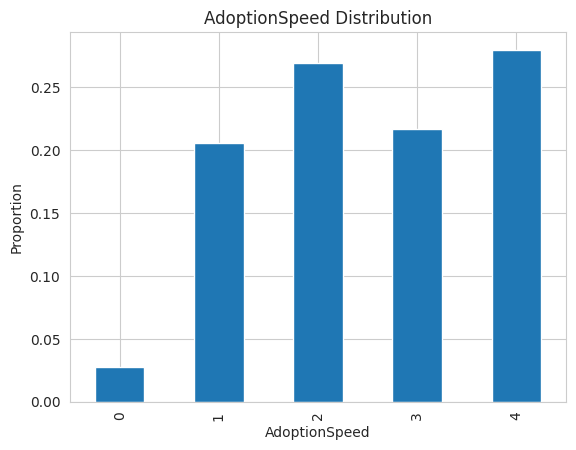

In [40]:
ax = target_proportions.plot(kind='bar')
ax.set_xlabel('AdoptionSpeed')
ax.set_ylabel('Proportion')
ax.set_title('AdoptionSpeed Distribution')
plt.show()

In [41]:
missing_count = train.isna().sum()
missing_pct = train.isna().mean() * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
Name,1265,8.437271
Description,13,0.086707


In [42]:
print('Empty Name:', (train['Name'].fillna('').str.strip() == '').sum())
print('Empty Description:', (train['Description'].fillna('').str.strip() == '').sum())

Empty Name: 1265
Empty Description: 13


In [43]:
print(train['Type'].value_counts(dropna=False).sort_index())
print(test['Type'].value_counts(dropna=False).sort_index())

Type
1    8132
2    6861
Name: count, dtype: int64
Type
1    2100
2    1872
Name: count, dtype: int64


In [44]:
print(train['Quantity'].describe())
print('\nQuantity frequencies:')
print(train['Quantity'].value_counts().sort_index().head(20))

count    14993.000000
mean         1.576069
std          1.472477
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         20.000000
Name: Quantity, dtype: float64

Quantity frequencies:
Quantity
1     11565
2      1422
3       726
4       531
5       333
6       185
7        84
8        52
9        33
10       19
11       10
12        6
13        2
14        2
15        4
16        3
17        3
18        1
20       12
Name: count, dtype: int64


In [45]:
breed_labels.head()

,BreedID,Type,BreedName
0,1,1,Affenpinscher
1,2,1,Afghan Hound
2,3,1,Airedale Terrier
3,4,1,Akbash
4,5,1,Akita


In [46]:
breed_check = train[['Type', 'Breed1', 'Breed2']].merge(
    breed_labels[['BreedID', 'Type']],
    left_on='Breed1',
    right_on='BreedID',
    how='left',
    suffixes=('_pet', '_breed')
)

breed_check['type_mismatch'] = (
    breed_check['BreedID'].notna() &
    (breed_check['Type_pet'] != breed_check['Type_breed'])
)

print('Breed1 rows with lookup match:', breed_check['BreedID'].notna().sum())
print('Breed1 type mismatches:', breed_check['type_mismatch'].sum())

Breed1 rows with lookup match: 14988
Breed1 type mismatches: 12


In [47]:
print('TRAIN SHAPE:', train.shape)
print('TEST SHAPE:', test.shape)

print('\nTRAIN/TEST COLUMN DIFFERENCE')
print('Only in train:', sorted(set(train.columns) - set(test.columns)))
print('Only in test:', sorted(set(test.columns) - set(train.columns)))

print('\nPETID')
print('Train unique:', train['PetID'].is_unique)
print('Test unique:', test['PetID'].is_unique)
print('Train/Test overlap:', len(set(train['PetID']) & set(test['PetID'])))

print('\nDUPLICATES')
print('Duplicate train rows:', train.duplicated().sum())
print('Duplicate test rows:', test.duplicated().sum())

print('\nTARGET')
print('Missing:', train['AdoptionSpeed'].isna().sum())
print('Values:', sorted(train['AdoptionSpeed'].dropna().unique()))

print('\nRESCUERID')
rescuer_counts = train['RescuerID'].value_counts()
print('Unique rescuers:', train['RescuerID'].nunique())
print('Rescuers with >1 listing:', (rescuer_counts > 1).sum())
print('Largest rescuer group:', rescuer_counts.max())

print('\nSEMANTIC EMPTY VALUES')
print('Empty Name:', train['Name'].fillna('').str.strip().eq('').sum())
print('Empty Description:', train['Description'].fillna('').str.strip().eq('').sum())

print('\nCATEGORICAL CODE RANGES')
for col in ['Type', 'Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health']:
    print(f'{col}:', sorted(train[col].dropna().unique()))

print('\nQUANTITY')
print(train['Quantity'].describe())
print('Max Quantity:', train['Quantity'].max())

TRAIN SHAPE: (14993, 24)
TEST SHAPE: (3972, 23)

TRAIN/TEST COLUMN DIFFERENCE
Only in train: ['AdoptionSpeed']
Only in test: []

PETID
Train unique: True
Test unique: True
Train/Test overlap: 0

DUPLICATES
Duplicate train rows: 0
Duplicate test rows: 0

TARGET
Missing: 0
Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

RESCUERID
Unique rescuers: 5595
Rescuers with >1 listing: 1812
Largest rescuer group: 459

SEMANTIC EMPTY VALUES
Empty Name: 1265
Empty Description: 13

CATEGORICAL CODE RANGES
Type: [np.int64(1), np.int64(2)]
Gender: [np.int64(1), np.int64(2), np.int64(3)]
MaturitySize: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
FurLength: [np.int64(1), np.int64(2), np.int64(3)]
Vaccinated: [np.int64(1), np.int64(2), np.int64(3)]
Dewormed: [np.int64(1), np.int64(2), np.int64(3)]
Sterilized: [np.int64(1), np.int64(2), np.int64(3)]
Health: [np.int64(1), np.int64(2), np.int64(3)]

QUANTITY
count    14993.000000
mean         1.576069
std          1.472477

In [48]:
expected_domains = {
    'Type': [1, 2],
    'Gender': [1, 2, 3],
    'MaturitySize': [0, 1, 2, 3, 4],
    'FurLength': [0, 1, 2, 3],
    'Vaccinated': [1, 2, 3],
    'Dewormed': [1, 2, 3],
    'Sterilized': [1, 2, 3],
    'Health': [0, 1, 2, 3]
}

for col, expected in expected_domains.items():
    train_values = sorted(train[col].dropna().unique())
    test_values = sorted(test[col].dropna().unique())
    invalid_train = sorted(set(train_values) - set(expected))
    invalid_test = sorted(set(test_values) - set(expected))

    print(f'\n{col}')
    print('Expected:', expected)
    print('Train observed:', train_values)
    print('Test observed:', test_values)
    print('Invalid train values:', invalid_train)
    print('Invalid test values:', invalid_test)


Type
Expected: [1, 2]
Train observed: [np.int64(1), np.int64(2)]
Test observed: [np.int64(1), np.int64(2)]
Invalid train values: []
Invalid test values: []

Gender
Expected: [1, 2, 3]
Train observed: [np.int64(1), np.int64(2), np.int64(3)]
Test observed: [np.int64(1), np.int64(2), np.int64(3)]
Invalid train values: []
Invalid test values: []

MaturitySize
Expected: [0, 1, 2, 3, 4]
Train observed: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Test observed: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Invalid train values: []
Invalid test values: []

FurLength
Expected: [0, 1, 2, 3]
Train observed: [np.int64(1), np.int64(2), np.int64(3)]
Test observed: [np.int64(1), np.int64(2), np.int64(3)]
Invalid train values: []
Invalid test values: []

Vaccinated
Expected: [1, 2, 3]
Train observed: [np.int64(1), np.int64(2), np.int64(3)]
Test observed: [np.int64(1), np.int64(2), np.int64(3)]
Invalid train values: []
Invalid test values: []

Dewormed
Expected: [1, 2, 3]
Train observe

In [49]:
print('BREED LABELS')
print('Columns:', breed_labels.columns.tolist())
print('Rows:', len(breed_labels))
print('Unique BreedID:', breed_labels['BreedID'].nunique())
print('Duplicate BreedID:', breed_labels['BreedID'].duplicated().sum())

print('\nBreed Type distribution:')
print(breed_labels['Type'].value_counts(dropna=False).sort_index())


print('\nCOLOR LABELS')
print('Columns:', color_labels.columns.tolist())
print('Rows:', len(color_labels))
print('Unique ColorID:', color_labels['ColorID'].nunique())
print('Duplicate ColorID:', color_labels['ColorID'].duplicated().sum())


print('\nSTATE LABELS')
print('Columns:', state_labels.columns.tolist())
print('Rows:', len(state_labels))
print('Unique StateID:', state_labels['StateID'].nunique())
print('Duplicate StateID:', state_labels['StateID'].duplicated().sum())


print('\nBREED COVERAGE')

breed_ids = set(breed_labels['BreedID'].dropna())

for col in ['Breed1', 'Breed2']:
    used_ids = set(train[col].dropna())
    missing_from_lookup = sorted(used_ids - breed_ids)

    print(f'\n{col}')
    print('Unique IDs used:', len(used_ids))
    print('IDs not in breed lookup:', missing_from_lookup[:20])
    print('Count not in lookup:', len(missing_from_lookup))


print('\nBREED TYPE CONSISTENCY')

breed_map = breed_labels.set_index('BreedID')['Type']

for col in ['Breed1', 'Breed2']:
    mapped_type = train[col].map(breed_map)

    mismatch = (
        mapped_type.notna() &
        (mapped_type != train['Type'])
    )

    print(f'{col} type mismatches:', mismatch.sum())


print('\nCOLOR COVERAGE')

color_ids = set(color_labels['ColorID'].dropna())

for col in ['Color1', 'Color2', 'Color3']:
    used_ids = set(train[col].dropna())
    missing_from_lookup = sorted(used_ids - color_ids)

    print(f'\n{col}')
    print('Unique IDs used:', len(used_ids))
    print('IDs not in color lookup:', missing_from_lookup)
    print('Count not in lookup:', len(missing_from_lookup))


print('\nSTATE COVERAGE')

state_ids = set(state_labels['StateID'].dropna())
used_state_ids = set(train['State'].dropna())
missing_states = sorted(used_state_ids - state_ids)

print('Unique states used:', len(used_state_ids))
print('States not in lookup:', missing_states)
print('Count not in lookup:', len(missing_states))

BREED LABELS
Columns: ['BreedID', 'Type', 'BreedName']
Rows: 307
Unique BreedID: 307
Duplicate BreedID: 0

Breed Type distribution:
Type
1    241
2     66
Name: count, dtype: int64

COLOR LABELS
Columns: ['ColorID', 'ColorName']
Rows: 7
Unique ColorID: 7
Duplicate ColorID: 0

STATE LABELS
Columns: ['StateID', 'StateName']
Rows: 15
Unique StateID: 15
Duplicate StateID: 0

BREED COVERAGE

Breed1
Unique IDs used: 176
IDs not in breed lookup: [0]
Count not in lookup: 1

Breed2
Unique IDs used: 135
IDs not in breed lookup: [0]
Count not in lookup: 1

BREED TYPE CONSISTENCY
Breed1 type mismatches: 12
Breed2 type mismatches: 3

COLOR COVERAGE

Color1
Unique IDs used: 7
IDs not in color lookup: []
Count not in lookup: 0

Color2
Unique IDs used: 7
IDs not in color lookup: [0]
Count not in lookup: 1

Color3
Unique IDs used: 6
IDs not in color lookup: [0]
Count not in lookup: 1

STATE COVERAGE
Unique states used: 14
States not in lookup: []
Count not in lookup: 0


In [50]:
from sklearn.metrics import cohen_kappa_score

baseline_results = []

for prediction in range(5):
    pred = np.full(len(train), prediction)
    qwk = cohen_kappa_score(
        train['AdoptionSpeed'],
        pred,
        weights='quadratic'
    )
    
    baseline_results.append({
        'constant_prediction': prediction,
        'qwk': qwk
    })

pd.DataFrame(baseline_results)

,constant_prediction,qwk
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0


In [51]:
majority_class = train['AdoptionSpeed'].mode()[0]

majority_pred = np.full(len(train), majority_class)

majority_qwk = cohen_kappa_score(
    train['AdoptionSpeed'],
    majority_pred,
    weights='quadratic'
)

print('Majority class:', majority_class)
print('Majority baseline QWK:', majority_qwk)

Majority class: 4
Majority baseline QWK: 0.0
